# Import Libraries

In [1]:
import sys
sys.path.insert(0,'/home/students/acct1002_02/anaconda3/envs/old_tf_gpu/lib/python3.6/site-packages')

In [2]:
import os
import numpy as np
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
#import tensorflow.keras as keras

from tensorflow.keras.layers import Input, Dense, Reshape, Flatten, Dropout, BatchNormalization, Activation, ZeroPadding2D, LeakyReLU, UpSampling2D, Conv2D, Conv2DTranspose, Concatenate
from tensorflow.keras.initializers import RandomNormal
#from keras_contrib.layers.normalization.instancenormalization import InstanceNormalization
#from tensorflow.keras.utils.vis_utils import plot_model
 
from tensorflow.keras.models import Sequential, Model
#import tensorflow.train.AdamOptimizer as Adam
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import img_to_array, load_img, array_to_img

from PIL import Image

/home/students/acct1002_02/anaconda3/envs/old_tf_gpu/lib/python3.6/site-packages/tensorflow/python/framework/dtypes.py:523: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
/home/students/acct1002_02/anaconda3/envs/old_tf_gpu/lib/python3.6/site-packages/tensorflow/python/framework/dtypes.py:524: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
/home/students/acct1002_02/anaconda3/envs/old_tf_gpu/lib/python3.6/site-packages/tensorflow/python/framework/dtypes.py:525: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int1

In [4]:
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

# Load Dataset (either normal or pneumonia dataset is loaded)

In [5]:
disease_class = {'Atelectasis': [],
                 'Cardiomegaly': [],
                 'Effusion': [],
                 'Infiltration': [],
                 'Mass': [],
                 'Nodule': [],
                 'Pneumonia': [],
                 'Pneumothorax': [],
                 'Consolidation': [],
                 'Edema': [],
                 'Emphysema': [],
                 'Fibrosis': [],
                 'Pleural_Thickening': [],
                 'Hernia': [],
                 'No Finding':[]}

#disease_rev = {v: k for k, v in disease_class.items()}

In [6]:
data_ref = pd.read_csv("CY1400/Data_Entry.csv")
pd.options.mode.chained_assignment = None        #ignore the SettingWithCopyWarning

for i in tqdm(range(len(data_ref))):
    #print(i)
    if ("|" not in data_ref['Finding Labels'][i]):
        disease_class[data_ref['Finding Labels'][i]].append(data_ref['Image Index'][i])

100%|██████████| 112120/112120 [00:01<00:00, 78908.43it/s]


In [6]:
for item in disease_class.keys():
    print(item, end=': ')
    print(len(disease_class[item]))

Atelectasis: 4215
Cardiomegaly: 1093
Effusion: 3955
Infiltration: 9547
Mass: 2139
Nodule: 2705
Pneumonia: 322
Pneumothorax: 2194
Consolidation: 1310
Edema: 628
Emphysema: 892
Fibrosis: 727
Pleural_Thickening: 1126
Hernia: 110
No Finding: 60361


In [99]:
train_image = []

#disease = 'Hernia'
#disease = 'Pneumonia'
#disease = 'Edema'
#disease = 'Fibrosis'
#disease = 'Emphysema'
#disease = 'Pleural_Thickening'
#disease = 'Consolidation'
#disease = 'Mass'
#disease = 'Pneumothorax'
#disease = 'Cardiomegaly'
#disease = 'Nodule'
#disease = 'Effusion'
#disease = 'Atelectasis'
#disease = 'Infiltration'
disease = 'No Finding'
image_name = disease_class[disease]

for i in tqdm(range(len(image_name))):
    #an image from original dataset

    img = image.load_img('CY1400/images/'+image_name[i],target_size=(128,128,1), grayscale=True)
    img = image.img_to_array(img)
    img = img/225.
    train_image.append(img)

X_train = np.array(train_image)

100%|██████████| 60361/60361 [09:17<00:00, 108.31it/s]


In [8]:
print(X_train.shape)

(110, 128, 128, 1)


# Build InstanceNormalization Layer

In [8]:
from tensorflow.keras.layers import Layer, InputSpec
from tensorflow.keras import initializers, regularizers, constraints
from tensorflow.keras import backend as K


class InstanceNormalization(Layer):
    def __init__(self,
                 axis=None,
                 epsilon=1e-3,
                 center=True,
                 scale=True,
                 beta_initializer='zeros',
                 gamma_initializer='ones',
                 beta_regularizer=None,
                 gamma_regularizer=None,
                 beta_constraint=None,
                 gamma_constraint=None,
                 **kwargs):
        super(InstanceNormalization, self).__init__(**kwargs)
        self.supports_masking = True
        self.axis = axis
        self.epsilon = epsilon
        self.center = center
        self.scale = scale
        self.beta_initializer = initializers.get(beta_initializer)
        self.gamma_initializer = initializers.get(gamma_initializer)
        self.beta_regularizer = regularizers.get(beta_regularizer)
        self.gamma_regularizer = regularizers.get(gamma_regularizer)
        self.beta_constraint = constraints.get(beta_constraint)
        self.gamma_constraint = constraints.get(gamma_constraint)

    def build(self, input_shape):
        ndim = len(input_shape)
        if self.axis == 0:
            raise ValueError('Axis cannot be zero')

        if (self.axis is not None) and (ndim == 2):
            raise ValueError('Cannot specify axis for rank 1 tensor')

        self.input_spec = InputSpec(ndim=ndim)

        if self.axis is None:
            shape = (1,)
        else:
            shape = (input_shape[self.axis],)

        if self.scale:
            self.gamma = self.add_weight(shape=shape,
                                         name='gamma',
                                         initializer=self.gamma_initializer,
                                         regularizer=self.gamma_regularizer,
                                         constraint=self.gamma_constraint)
        else:
            self.gamma = None
        if self.center:
            self.beta = self.add_weight(shape=shape,
                                        name='beta',
                                        initializer=self.beta_initializer,
                                        regularizer=self.beta_regularizer,
                                        constraint=self.beta_constraint)
        else:
            self.beta = None
        self.built = True

    def call(self, inputs, training=None):
        input_shape = K.int_shape(inputs)
        reduction_axes = list(range(0, len(input_shape)))

        if self.axis is not None:
            del reduction_axes[self.axis]

        del reduction_axes[0]

        mean = K.mean(inputs, reduction_axes, keepdims=True)
        stddev = K.std(inputs, reduction_axes, keepdims=True) + self.epsilon
        normed = (inputs - mean) / stddev

        broadcast_shape = [1] * len(input_shape)
        if self.axis is not None:
            broadcast_shape[self.axis] = input_shape[self.axis]

        if self.scale:
            broadcast_gamma = K.reshape(self.gamma, broadcast_shape)
            normed = normed * broadcast_gamma
        if self.center:
            broadcast_beta = K.reshape(self.beta, broadcast_shape)
            normed = normed + broadcast_beta
        return normed

    def get_config(self):
        config = {
            'axis': self.axis,
            'epsilon': self.epsilon,
            'center': self.center,
            'scale': self.scale,
            'beta_initializer': initializers.serialize(self.beta_initializer),
            'gamma_initializer': initializers.serialize(self.gamma_initializer),
            'beta_regularizer': regularizers.serialize(self.beta_regularizer),
            'gamma_regularizer': regularizers.serialize(self.gamma_regularizer),
            'beta_constraint': constraints.serialize(self.beta_constraint),
            'gamma_constraint': constraints.serialize(self.gamma_constraint)
        }
        base_config = super(InstanceNormalization, self).get_config()
        return dict(list(base_config.items()) + list(config.items()))

# 3. Build cycleGAN

In [9]:
def _check_trainable_weights_consistency(self):
    return
Model._check_trainable_weights_consistency = _check_trainable_weights_consistency

In [18]:
class cycleGAN():
    def __init__(self):
        self.img_rows = 128
        self.img_cols = 128
        self.channels = 1
        self.img_shape = (self.img_rows, self.img_cols, self.channels)
        self.latent_dim = 100
        self.history = []
        
        self.g_model_AtoB = self.define_generator()
        # generator: B -> A
        self.g_model_BtoA = self.define_generator()
        # discriminator: A -> [real/fake]
        self.d_model_A = self.define_discriminator()
        # discriminator: B -> [real/fake]
        self.d_model_B = self.define_discriminator()
        # composite: A -> B -> [real/fake, A]
        self.c_model_AtoB = self.define_composite_model(self.g_model_AtoB, self.d_model_B, self.g_model_BtoA, self.img_shape)
        # composite: B -> A -> [real/fake, B]
        self.c_model_BtoA = self.define_composite_model(self.g_model_BtoA, self.d_model_A, self.g_model_AtoB, self.img_shape)
        
        #train(d_model_A, d_model_B, g_model_AtoB, g_model_BtoA, c_model_AtoB, c_model_BtoA, X_train)
        
    def define_discriminator(self):
        init = RandomNormal(stddev=0.02)
        in_image = Input(shape=(128,128,1))

        d = Conv2D(64, (4,4), padding='same', kernel_initializer=init)(in_image)
        d = LeakyReLU(alpha=0.2)(d)
        # C128
        d = Conv2D(128, (4,4), strides=(2,2), padding='same', kernel_initializer=init)(d)
        d = InstanceNormalization(axis=-1)(d)
        d = LeakyReLU(alpha=0.2)(d)
        # C256
        d = Conv2D(256, (4,4), strides=(2,2), padding='same', kernel_initializer=init)(d)
        d = InstanceNormalization(axis=-1)(d)
        d = LeakyReLU(alpha=0.2)(d)
        # C512
        d = Conv2D(512, (4,4), strides=(2,2), padding='same', kernel_initializer=init)(d)
        d = InstanceNormalization(axis=-1)(d)
        d = LeakyReLU(alpha=0.2)(d)
        # second last output layer
        #d = Conv2D(512, (4,4), padding='same', kernel_initializer=init)(d)
        #d = BatchNormalization(axis=-1)(d)
        #d = LeakyReLU(alpha=0.2)(d)
        # patch output
        patch_out = Conv2D(1, (4,4), padding='same', kernel_initializer=init)(d)
        # define model
        model = Model(in_image, patch_out)
        # compile model
        model.compile(loss='mse', optimizer=Adam(lr=0.002, beta_1=0.5), loss_weights=[0.5])
        return model

    # generator a resnet block
    def resnet_block(self, n_filters, input_layer):
        # weight initialization
        init = RandomNormal(stddev=0.02)
        # first layer convolutional layer
        g = Conv2D(n_filters, (3,3), padding='same', kernel_initializer=init)(input_layer)
        g = InstanceNormalization(axis=-1)(g)
        g = Activation('relu')(g)
        # second convolutional layer
        g = Conv2D(n_filters, (3,3), padding='same', kernel_initializer=init)(g)
        g = InstanceNormalization(axis=-1)(g)
        # concatenate merge channel-wise with input layer
        g = Concatenate()([g, input_layer])
        return g

    # define the standalone generator model
    def define_generator(self, n_resnet=9):
        
        
        # weight initialization
        init = RandomNormal(stddev=0.02)
        # image input
        in_image = Input(shape=(128,128,1))
        # c7s1-64
        g = Conv2D(128, (7,7), padding='same', kernel_initializer=init)(in_image)
        g = InstanceNormalization(axis=-1)(g)
        g = Activation('relu')(g)
        # d128
        #g = Conv2D(128, (3,3), strides=(2,2), padding='same', kernel_initializer=init)(g)
        #g = InstanceNormalization(axis=-1)(g)
        #g = Activation('relu')(g)
        # d256
        g = Conv2D(256, (3,3), strides=(2,2), padding='same', kernel_initializer=init)(g)
        g = InstanceNormalization(axis=-1)(g)
        g = Activation('relu')(g)
        # R256
        #for i in range(9):
        g = self.resnet_block(256, g)
        # u128
        g = Conv2DTranspose(128, (3,3), strides=(2,2), padding='same', kernel_initializer=init)(g)
        g = InstanceNormalization(axis=-1)(g)
        g = Activation('relu')(g)
        # u64
        #g = Conv2DTranspose(64, (3,3), strides=(2,2), padding='same', kernel_initializer=init)(g)
        #g = BatchNormalization(axis=-1)(g)
        #g = Activation('relu')(g)
        # c7s1-3
        g = Conv2D(1, (7,7), padding='same', kernel_initializer=init)(g)
        g = InstanceNormalization(axis=-1)(g)
        out_image = Activation('tanh')(g)
        # define model
        model = Model(in_image, out_image)
        return model

    # define a composite model for updating generators by adversarial and cycle loss
    def define_composite_model(self, g_model_1, d_model, g_model_2, image_shape):
        # ensure the model we're updating is trainable
        g_model_1.trainable = True
        # mark discriminator as not trainable
        d_model.trainable = False
        # mark other generator model as not trainable
        g_model_2.trainable = False
        # discriminator element
        input_gen = Input(shape=(128,128,1))
        gen1_out = g_model_1(input_gen)
        output_d = d_model(gen1_out)
        # identity element
        input_id = Input(shape=(128,128,1))
        output_id = g_model_1(input_id)
        # forward cycle
        output_f = g_model_2(gen1_out)
        # backward cycle
        gen2_out = g_model_2(input_id)
        output_b = g_model_1(gen2_out)
        # define model graph
        model = Model([input_gen, input_id], [output_d, output_id, output_f, output_b])
        # define optimization algorithm configuration
        opt = Adam(lr=0.002, beta_1=0.5)
        # compile model with weighting of least squares loss and L1 loss
        model.compile(loss=['mse', 'mae', 'mae', 'mae'], loss_weights=[1, 5, 10, 10], optimizer=opt)
        return model

    def generate_real_samples(self, dataset, n_samples, patch_shape):
        # choose random instances
        ix = np.random.randint(0, dataset.shape[0], n_samples)
        # retrieve selected images
        X = dataset[ix]
        # generate 'real' class labels (1)
        #print(n_samples, patch_shape, patch_shape)
        y = np.ones((n_samples, patch_shape, patch_shape, 1))
        return X, y

    def generate_fake_samples(self, g_model, dataset, patch_shape):
        # generate fake instance
        X = g_model.predict(dataset)
        # create 'fake' class labels (0)
        y = np.zeros((len(X), patch_shape, patch_shape, 1))
        return X, y

    def update_image_pool(self, pool, images, max_size=50):
        selected = list()
        for image in images:
            if len(pool) < max_size:
                # stock the pool
                pool.append(image)
                selected.append(image)
            elif np.random.random() < 0.5:
                # use image, but don't add it to the pool
                selected.append(image)
            else:
                # replace an existing image and use replaced image
                ix = np.random.randint(0, len(pool))
                selected.append(pool[ix])
                pool[ix] = image
        return np.asarray(selected)

    
    #def train(d_model_A, d_model_B, g_model_AtoB, g_model_BtoA, c_model_AtoB, c_model_BtoA, dataset):
    def train(self, batch_size, epoch, step):

        # define properties of the training run
        n_epochs, n_batch, = epoch, batch_size
        # determine the output square shape of the discriminator
        #n_patch = self.d_model_A.output_shape[1]

        n_patch = self.d_model_A.get_output_at(-1).get_shape().as_list()[1]
        # unpack dataset
        trainA, trainB = X_train[:len(X_train)//2], X_train[len(X_train)//2:]

        # prepare image pool for fakes
        poolA, poolB = list(), list()
        # calculate the number of batches per training epoch
        bat_per_epo = int(len(trainA) / n_batch)
        # calculate the number of training iterations
        n_steps = bat_per_epo * n_epochs
        # manually enumerate epochs

        for i in range(n_steps):
            # select a batch of real samples
            X_realA, y_realA = self.generate_real_samples(trainA, n_batch, n_patch)
            X_realB, y_realB = self.generate_real_samples(trainB, n_batch, n_patch)
            # generate a batch of fake samples
            X_fakeA, y_fakeA = self.generate_fake_samples(self.g_model_BtoA, X_realB, n_patch)
            X_fakeB, y_fakeB = self.generate_fake_samples(self.g_model_AtoB, X_realA, n_patch)

            # update fakes from pool
            X_fakeA = self.update_image_pool(poolA, X_fakeA)
            X_fakeB = self.update_image_pool(poolB, X_fakeB)
            # update generator B->A via adversarial and cycle loss
            g_loss2, _, _, _, _  = self.c_model_BtoA.train_on_batch([X_realB, X_realA], [y_realA, X_realA, X_realB, X_realA])
            # update discriminator for A -> [real/fake]
            dA_loss1 = self.d_model_A.train_on_batch(X_realA, y_realA)
            dA_loss2 = self.d_model_A.train_on_batch(X_fakeA, y_fakeA)
            # update generator A->B via adversarial and cycle loss
            g_loss1, _, _, _, _ = self.c_model_AtoB.train_on_batch([X_realA, X_realB], [y_realB, X_realB, X_realA, X_realB])
            # update discriminator for B -> [real/fake]
            dB_loss1 = self.d_model_B.train_on_batch(X_realB, y_realB)
            dB_loss2 = self.d_model_B.train_on_batch(X_fakeB, y_fakeB)
            # summarize performance
            print('>%d, dA[%.3f,%.3f] dB[%.3f,%.3f] g[%.3f,%.3f]' % (i+1, dA_loss1,dA_loss2, dB_loss1,dB_loss2, g_loss1,g_loss2))
            
            if (i+1) % step == 0:
                self.sample_images(i+1, X_realA[0], X_realB[0])

    def sample_images(self, batch_i, imgs_A, imgs_B):
        r, c = 2, 3
        imgs_A= imgs_A.reshape(1, 128,128,1)
        imgs_B= imgs_B.reshape(1, 128, 128, 1)
        # Translate images to the other domain
        fake_B = self.g_model_AtoB.predict(imgs_A)
        fake_A = self.g_model_BtoA.predict(imgs_B)
        # Translate back to original domain
        reconstr_A = self.g_model_BtoA.predict(fake_B)
        reconstr_B = self.g_model_AtoB.predict(fake_A)

        gen_imgs = np.concatenate([imgs_A, fake_B, reconstr_A, imgs_B, fake_A, reconstr_B])

        # Rescale images 0 - 1
        gen_imgs = 0.5 * gen_imgs + 0.5

        titles = ['Original', 'Translated', 'Reconstructed']
        fig, axs = plt.subplots(r, c)
        fig.patch.set_visible(False)
        cnt = 0
        for i in range(r):
            for j in range(c):
                axs[i,j].imshow(gen_imgs[cnt],  cmap='gray')
                axs[i, j].set_title(titles[j])
                axs[i,j].axis('off')
                cnt += 1
        fig.savefig("test_GAN/%d.png" % (batch_i), formats = 'png', cmap='gray', bbox_tight = True)
        plt.close()

    def gen(self):
        generated = self.g_model_BtoA.predict(X_train)
        re_gen = self.g_model_AtoB.predict(generated)

        new_generated = 0.5 * re_gen + 0.5
        return new_generated
            

# Train with data with performance

In [19]:
if __name__ == '__main__':
    cgan = cycleGAN()
    cgan.train(epoch=1000, batch_size=16, step = 300)

>1, dA[1.598,24.516] dB[0.737,15.833] g[17.900,20.928]
>2, dA[37.150,16.366] dB[77.612,3.827] g[107.339,129.670]
>3, dA[2.904,5.087] dB[5.375,1.749] g[25.856,25.174]
>4, dA[0.941,1.734] dB[0.691,1.378] g[15.958,18.210]
>5, dA[0.411,0.665] dB[0.302,0.346] g[13.553,14.548]
>6, dA[0.321,0.559] dB[0.265,0.404] g[11.957,12.570]
>7, dA[0.379,0.268] dB[0.223,0.212] g[11.835,12.490]
>8, dA[0.306,0.377] dB[0.190,0.256] g[11.832,12.328]
>9, dA[0.347,0.338] dB[0.225,0.167] g[11.588,12.072]
>10, dA[0.315,0.353] dB[0.190,0.251] g[11.724,12.337]
>11, dA[0.402,0.441] dB[0.201,0.167] g[11.010,11.598]
>12, dA[0.485,0.424] dB[0.184,0.232] g[10.975,11.818]
>13, dA[0.336,0.319] dB[0.228,0.180] g[11.241,11.552]
>14, dA[0.326,0.379] dB[0.179,0.207] g[10.690,11.009]
>15, dA[0.443,0.459] dB[0.169,0.184] g[10.528,11.358]
>16, dA[0.398,0.340] dB[0.197,0.191] g[11.404,11.832]
>17, dA[0.352,0.402] dB[0.183,0.192] g[10.523,11.023]
>18, dA[0.400,0.414] dB[0.174,0.167] g[10.678,10.973]
>19, dA[0.377,0.377] dB[0.177,

>156, dA[0.017,0.011] dB[0.804,0.157] g[9.867,7.626]
>157, dA[0.013,0.010] dB[0.289,0.754] g[6.508,6.952]
>158, dA[0.011,0.007] dB[0.711,0.384] g[7.274,6.657]
>159, dA[0.016,0.019] dB[0.335,1.459] g[6.941,7.565]
>160, dA[0.012,0.021] dB[1.387,0.343] g[10.001,6.753]
>161, dA[0.014,0.018] dB[0.896,0.198] g[6.210,7.409]
>162, dA[0.023,0.020] dB[0.533,0.573] g[7.050,6.672]
>163, dA[0.016,0.024] dB[0.353,0.893] g[6.202,6.255]
>164, dA[0.017,0.016] dB[0.822,0.440] g[9.538,7.340]
>165, dA[0.027,0.029] dB[0.265,0.378] g[6.077,7.174]
>166, dA[0.024,0.020] dB[0.459,0.634] g[6.568,6.218]
>167, dA[0.022,0.010] dB[0.419,1.479] g[5.627,6.374]
>168, dA[0.019,0.022] dB[1.027,0.987] g[9.456,7.185]
>169, dA[0.019,0.009] dB[0.961,0.327] g[5.937,6.803]
>170, dA[0.020,0.011] dB[1.365,0.999] g[7.496,6.023]
>171, dA[0.017,0.015] dB[1.900,1.933] g[6.041,6.474]
>172, dA[0.019,0.007] dB[3.780,2.550] g[10.768,6.570]
>173, dA[0.025,0.011] dB[2.515,0.415] g[7.117,6.759]
>174, dA[0.012,0.013] dB[2.162,0.977] g[8.97

/home/students/acct1002_02/.local/lib/python3.6/site-packages/ipykernel_launcher.py:244: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "formats" which is no longer supported as of 3.3 and will become an error two minor releases later
/home/students/acct1002_02/.local/lib/python3.6/site-packages/ipykernel_launcher.py:244: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "cmap" which is no longer supported as of 3.3 and will become an error two minor releases later
/home/students/acct1002_02/.local/lib/python3.6/site-packages/ipykernel_launcher.py:244: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "bbox_tight" which is no longer supported as of 3.3 and will become an error two minor releases later


>301, dA[0.003,0.004] dB[0.005,0.007] g[5.485,5.419]
>302, dA[0.005,0.002] dB[0.006,0.004] g[4.925,5.134]
>303, dA[0.009,0.017] dB[0.006,0.003] g[5.559,5.749]
>304, dA[0.009,0.031] dB[0.005,0.005] g[4.843,5.166]
>305, dA[0.011,0.021] dB[0.004,0.002] g[4.498,4.508]
>306, dA[0.016,0.006] dB[0.004,0.003] g[4.979,5.344]
>307, dA[0.016,0.015] dB[0.005,0.002] g[5.149,5.081]
>308, dA[0.010,0.010] dB[0.004,0.004] g[4.972,5.440]
>309, dA[0.008,0.011] dB[0.005,0.003] g[4.874,4.957]
>310, dA[0.007,0.020] dB[0.005,0.004] g[4.717,4.809]
>311, dA[0.010,0.018] dB[0.007,0.005] g[4.685,4.698]
>312, dA[0.015,0.023] dB[0.004,0.005] g[5.341,5.585]
>313, dA[0.018,0.018] dB[0.004,0.003] g[4.809,4.771]
>314, dA[0.021,0.022] dB[0.005,0.004] g[4.762,5.015]
>315, dA[0.016,0.012] dB[0.007,0.005] g[5.086,5.173]
>316, dA[0.019,0.018] dB[0.006,0.002] g[4.550,5.003]
>317, dA[0.028,0.054] dB[0.008,0.010] g[5.030,4.934]
>318, dA[0.063,0.185] dB[0.006,0.004] g[4.777,5.216]
>319, dA[0.073,0.233] dB[0.005,0.005] g[5.411,

>456, dA[0.023,0.024] dB[0.019,0.013] g[4.558,4.497]
>457, dA[0.020,0.026] dB[0.011,0.015] g[3.948,3.831]
>458, dA[0.014,0.027] dB[0.018,0.014] g[4.146,4.157]
>459, dA[0.015,0.014] dB[0.019,0.021] g[3.835,4.003]
>460, dA[0.016,0.009] dB[0.020,0.015] g[3.781,4.243]
>461, dA[0.018,0.022] dB[0.010,0.010] g[4.003,4.584]
>462, dA[0.021,0.026] dB[0.007,0.006] g[4.082,4.365]
>463, dA[0.023,0.024] dB[0.007,0.009] g[3.955,3.894]
>464, dA[0.057,0.045] dB[0.010,0.009] g[3.713,4.169]
>465, dA[0.053,0.043] dB[0.006,0.014] g[4.209,3.793]
>466, dA[0.126,0.135] dB[0.008,0.008] g[4.633,5.061]
>467, dA[0.055,0.056] dB[0.010,0.015] g[3.943,3.769]
>468, dA[0.110,0.102] dB[0.012,0.005] g[4.194,4.213]
>469, dA[0.045,0.054] dB[0.012,0.008] g[4.202,4.234]
>470, dA[0.135,0.126] dB[0.011,0.014] g[4.189,4.760]
>471, dA[0.065,0.022] dB[0.014,0.007] g[4.081,3.739]
>472, dA[0.075,0.059] dB[0.010,0.014] g[4.247,3.829]
>473, dA[0.022,0.018] dB[0.020,0.008] g[3.842,4.100]
>474, dA[0.021,0.009] dB[0.019,0.035] g[4.010,

...

>2291, dA[0.133,0.126] dB[0.125,0.132] g[2.047,1.821]
>2292, dA[0.127,0.127] dB[0.119,0.099] g[2.118,1.910]
>2293, dA[0.139,0.136] dB[0.149,0.134] g[1.765,1.671]
>2294, dA[0.136,0.128] dB[0.148,0.139] g[2.251,1.977]
>2295, dA[0.134,0.124] dB[0.117,0.121] g[2.167,1.987]
>2296, dA[0.136,0.129] dB[0.125,0.125] g[1.930,1.650]
>2297, dA[0.131,0.123] dB[0.133,0.106] g[2.121,1.868]
>2298, dA[0.128,0.133] dB[0.128,0.119] g[2.109,1.965]
>2299, dA[0.135,0.135] dB[0.114,0.105] g[2.273,2.137]
>2300, dA[0.128,0.127] dB[0.104,0.111] g[1.897,1.866]
>2301, dA[0.141,0.134] dB[0.125,0.116] g[1.927,1.790]
>2302, dA[0.139,0.128] dB[0.102,0.115] g[2.000,1.882]
>2303, dA[0.134,0.127] dB[0.094,0.121] g[2.415,2.228]
>2304, dA[0.131,0.130] dB[0.151,0.157] g[2.061,1.861]
>2305, dA[0.133,0.123] dB[0.133,0.153] g[1.768,1.472]
>2306, dA[0.132,0.128] dB[0.141,0.130] g[2.225,1.882]
>2307, dA[0.136,0.131] dB[0.122,0.092] g[2.090,1.848]
>2308, dA[0.128,0.128] dB[0.105,0.090] g[2.117,1.805]
>2309, dA[0.131,0.116] dB[0.

>2443, dA[0.137,0.124] dB[0.092,0.078] g[2.363,2.230]
>2444, dA[0.125,0.126] dB[0.136,0.126] g[2.281,1.980]
>2445, dA[0.127,0.135] dB[0.123,0.130] g[2.548,1.934]
>2446, dA[0.130,0.136] dB[0.170,0.203] g[2.077,1.778]
>2447, dA[0.134,0.142] dB[0.194,0.142] g[2.623,2.283]
>2448, dA[0.139,0.122] dB[0.133,0.146] g[2.064,1.740]
>2449, dA[0.121,0.126] dB[0.128,0.106] g[1.823,1.655]
>2450, dA[0.140,0.129] dB[0.117,0.138] g[2.301,2.149]
>2451, dA[0.127,0.132] dB[0.140,0.153] g[2.060,1.744]
>2452, dA[0.134,0.129] dB[0.154,0.174] g[2.095,1.618]
>2453, dA[0.132,0.131] dB[0.167,0.112] g[2.169,1.691]
>2454, dA[0.150,0.140] dB[0.118,0.129] g[2.047,1.730]
>2455, dA[0.136,0.131] dB[0.103,0.119] g[1.888,1.727]
>2456, dA[0.145,0.128] dB[0.085,0.075] g[2.409,2.104]
>2457, dA[0.138,0.140] dB[0.115,0.081] g[1.963,1.747]
>2458, dA[0.158,0.131] dB[0.117,0.159] g[2.058,1.919]
>2459, dA[0.143,0.139] dB[0.131,0.160] g[2.539,2.026]
>2460, dA[0.132,0.133] dB[0.162,0.204] g[2.416,1.986]
>2461, dA[0.140,0.129] dB[0.

>2595, dA[0.136,0.131] dB[0.078,0.103] g[2.450,2.069]
>2596, dA[0.156,0.139] dB[0.053,0.076] g[2.426,2.152]
>2597, dA[0.132,0.129] dB[0.146,0.176] g[1.839,1.561]
>2598, dA[0.129,0.146] dB[0.171,0.141] g[2.169,1.721]
>2599, dA[0.138,0.143] dB[0.262,0.284] g[2.754,2.182]
>2600, dA[0.142,0.127] dB[0.126,0.082] g[2.093,1.560]
>2601, dA[0.124,0.127] dB[0.081,0.051] g[2.339,1.762]
>2602, dA[0.148,0.135] dB[0.093,0.118] g[2.054,1.533]
>2603, dA[0.133,0.136] dB[0.080,0.062] g[2.283,1.768]
>2604, dA[0.128,0.130] dB[0.071,0.067] g[2.109,1.677]
>2605, dA[0.156,0.147] dB[0.108,0.107] g[2.286,1.962]
>2606, dA[0.152,0.130] dB[0.107,0.094] g[2.098,1.757]
>2607, dA[0.124,0.119] dB[0.085,0.099] g[2.657,1.945]
>2608, dA[0.141,0.127] dB[0.057,0.135] g[1.756,1.588]
>2609, dA[0.136,0.116] dB[0.092,0.121] g[2.129,1.834]
>2610, dA[0.129,0.136] dB[0.090,0.113] g[2.270,1.937]
>2611, dA[0.130,0.126] dB[0.093,0.073] g[2.000,1.554]
>2612, dA[0.136,0.128] dB[0.103,0.085] g[2.040,1.639]
>2613, dA[0.133,0.126] dB[0.

>2747, dA[0.160,0.124] dB[0.114,0.119] g[2.035,1.876]
>2748, dA[0.118,0.132] dB[0.125,0.125] g[1.990,1.877]
>2749, dA[0.127,0.143] dB[0.104,0.117] g[1.705,1.569]
>2750, dA[0.138,0.123] dB[0.100,0.127] g[1.885,1.686]
>2751, dA[0.119,0.115] dB[0.128,0.106] g[1.906,1.697]
>2752, dA[0.145,0.124] dB[0.103,0.113] g[1.660,1.663]
>2753, dA[0.125,0.126] dB[0.094,0.137] g[2.377,2.099]
>2754, dA[0.141,0.122] dB[0.152,0.102] g[1.676,1.538]
>2755, dA[0.132,0.134] dB[0.131,0.105] g[2.046,1.761]
>2756, dA[0.130,0.127] dB[0.077,0.106] g[2.018,1.661]
>2757, dA[0.136,0.117] dB[0.092,0.134] g[1.880,1.762]
>2758, dA[0.130,0.133] dB[0.152,0.125] g[1.881,1.719]
>2759, dA[0.116,0.122] dB[0.136,0.090] g[2.133,1.952]
>2760, dA[0.136,0.140] dB[0.091,0.074] g[2.315,1.889]
>2761, dA[0.136,0.123] dB[0.094,0.098] g[2.285,2.241]
>2762, dA[0.136,0.123] dB[0.091,0.138] g[1.792,1.684]
>2763, dA[0.151,0.133] dB[0.091,0.092] g[1.632,1.518]
>2764, dA[0.116,0.133] dB[0.087,0.105] g[1.804,1.556]
>2765, dA[0.146,0.120] dB[0.

>2899, dA[0.131,0.115] dB[0.060,0.157] g[1.768,1.904]
>2900, dA[0.122,0.145] dB[0.103,0.102] g[2.113,1.915]
>2901, dA[0.128,0.135] dB[0.122,0.100] g[2.547,1.834]
>2902, dA[0.141,0.152] dB[0.107,0.136] g[1.993,1.809]
>2903, dA[0.149,0.141] dB[0.160,0.078] g[2.102,1.876]
>2904, dA[0.126,0.121] dB[0.106,0.109] g[2.080,1.774]
>2905, dA[0.127,0.120] dB[0.087,0.105] g[1.811,1.560]
>2906, dA[0.125,0.127] dB[0.078,0.138] g[2.014,1.824]
>2907, dA[0.155,0.136] dB[0.114,0.106] g[1.827,1.768]
>2908, dA[0.144,0.127] dB[0.113,0.140] g[1.993,1.925]
>2909, dA[0.135,0.117] dB[0.125,0.099] g[1.876,1.616]
>2910, dA[0.121,0.127] dB[0.124,0.135] g[1.663,1.622]
>2911, dA[0.145,0.169] dB[0.109,0.129] g[1.870,1.684]
>2912, dA[0.136,0.111] dB[0.120,0.097] g[2.193,1.906]
>2913, dA[0.133,0.137] dB[0.136,0.129] g[1.813,1.620]
>2914, dA[0.146,0.138] dB[0.124,0.155] g[1.720,1.590]
>2915, dA[0.126,0.122] dB[0.137,0.159] g[1.697,1.506]
>2916, dA[0.135,0.133] dB[0.136,0.137] g[1.993,1.748]
>2917, dA[0.129,0.106] dB[0.

# Synthesise and save images

In [100]:
gan_images = cgan.gen()

In [101]:
# Img name starts with GG:cycleGAN, starts with G: DCGAN
for i in tqdm(range(len(image_name))):
    plt.imsave("GAN/GG"+image_name[i], gan_images[i,:,:,0], cmap = 'gray')

100%|██████████| 60361/60361 [04:14<00:00, 237.29it/s]


(-0.5, 127.5, 127.5, -0.5)

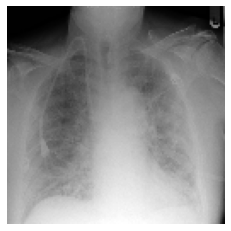

In [63]:
plt.imshow(X_train[20,:,:,0], cmap = 'gray')
plt.axis('off')

(-0.5, 127.5, 127.5, -0.5)

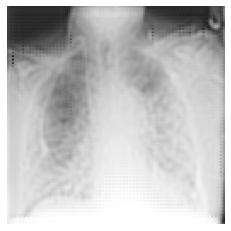

In [64]:
plt.imshow(gan_images[20,:,:,0], cmap = 'gray')
plt.axis('off')